# Exercise: Undercomplete Autoencoder with Convolutional Layers

In this exercise, we will implement an undercomplete autoencoder using convolutional layers. We will use the MNIST dataset, which consists of 28x28 grayscale images of handwritten digits.

In [19]:
from torchvision.datasets.mnist import MNIST
from torchvision.transforms import ToTensor, Compose, Normalize
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch
import numpy as np
import matplotlib.pyplot as plt

if torch.backends.cuda.is_built():
    device = torch.device('cuda')
elif torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

mnist_train = MNIST('./data', download=True, transform=ToTensor())
mnist_test = MNIST('./data', download=True, train=False, transform=ToTensor())


mnist_train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=64, shuffle=True)

Using device: cpu


# Exercise description

Objective of this exercise is to develop an undercomplete autoencoder, gain an apreciation for how well the reconstruction is and visualize how the examples are distributed in the embedding space.

The autoencoder will be based on a convolutional architecture with the following specs:

## Encoder Layers:

- encoder1: Convolutional layer with 1 input channel, 16 output channels, a kernel size of 3, stride of 2, and padding of 1. Relu activation.
- encoder2: Convolutional layer with 16 input channels, 32 output channels, a kernel size of 3, stride of 2, and padding of 1. Relu activation.
- encoder3: Convolutional layer with 32 input channels, 64 output channels, a kernel size of 7, stride of 1, and no padding. Relu activation.
- encoder4: Fully connected (linear) layer reducing the dimensionality to z_size. **No activation**. It's very important for latent space

## Decoder Layers:

- decoder1: Fully connected (linear) layer increasing the dimensionality from z_size to 64. Relu activation.
- decoder2: Transposed convolutional layer with 64 input channels, 32 output channels, a kernel size of 7, stride of 1, and no padding. Relu activation.
- decoder3: Transposed convolutional layer with 32 input channels, 16 output channels, a kernel size of 3, stride of 2, padding of 1, and output padding of 1. Relu activation.
- decoder4: Transposed convolutional layer with 16 input channels, 1 output channel, a kernel size of 3, stride of 2, padding of 1, and output padding of 1. Relu activation.

where z_size is a parameter of the model specifying the size of the embedding space.



In [20]:
class Model(torch.nn.Module):
  def __init__(self, z_size=3):
      super(Model, self).__init__()
      self.z_size = z_size

      self.encoder1 = torch.nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)
      self.encoder2 = torch.nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
      self.encoder3 = torch.nn.Conv2d(32, 64, kernel_size=7, stride=1, padding=0)
      self.encoder4 = torch.nn.Linear(64, z_size) # -> to latent space

      self.decoder1 = torch.nn.Linear(z_size, 64) # -> from latent space
      self.decoder2 = torch.nn.ConvTranspose2d(64, 32, kernel_size=7, stride=1, padding=0)
      self.decoder3 = torch.nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1)
      self.decoder4 = torch.nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1)

  def encode(self, x):
        x = F.relu(self.encoder1(x))
        x = F.relu(self.encoder2(x))
        x = F.relu(self.encoder3(x))
        x = x.view(-1, 64)
        x = self.encoder4(x)

        return x

  def decode(self, z):
        z = F.relu(self.decoder1(z))
        z = z.view(-1, 64, 1, 1)
        z = F.relu(self.decoder2(z))
        z = F.relu(self.decoder3(z))
        z = F.relu(self.decoder4(z))

        return z

  def forward(self, x):
        x = self.encode(x)
        x = self.decode(x)
        return x

  def generate(self):
        x = torch.rand(1, self.z_size).to(device)
        x = self.decode(x)
        return x

In [30]:
# model = Model(z_size=20).to(device)
# if you want to generate image you have to modify z_size in 3
model = Model(z_size=3).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
loss_fn = torch.nn.MSELoss()

losses = []
tot_epochs=0

In [31]:
epochs = 5
for epoch in range(epochs):
    tot_epochs+=1
    train_loss = 0
    for i, (images, _) in enumerate(mnist_train_loader):
        images = images.to(device)
        outputs = model(images)

        loss = loss_fn(outputs, images)

        train_loss += loss.item()
        losses.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, epochs, train_loss / len(mnist_train_loader)))

print(f"Total epochs done so far: {tot_epochs}")

Epoch [1/5], Loss: 0.0606
Epoch [2/5], Loss: 0.0468
Epoch [3/5], Loss: 0.0448
Epoch [4/5], Loss: 0.0435
Epoch [5/5], Loss: 0.0424
Total epochs done so far: 5


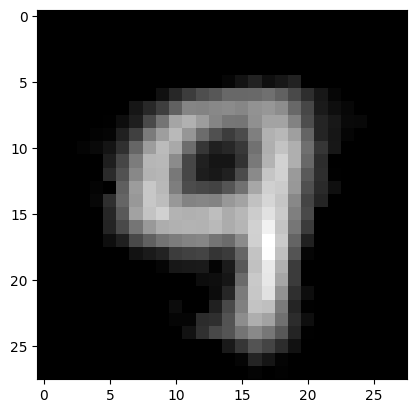

In [32]:
img = model(mnist_test[4][0].to(device)).clip(0, 1).cpu().detach().numpy()
plt.imshow(img.reshape(28,28), cmap='gray')

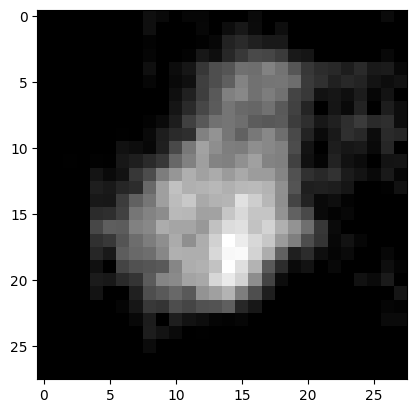

In [33]:
gen = model.generate().clip(0, 1).cpu().detach().numpy().reshape(28,28)
plt.imshow(gen, cmap='gray')

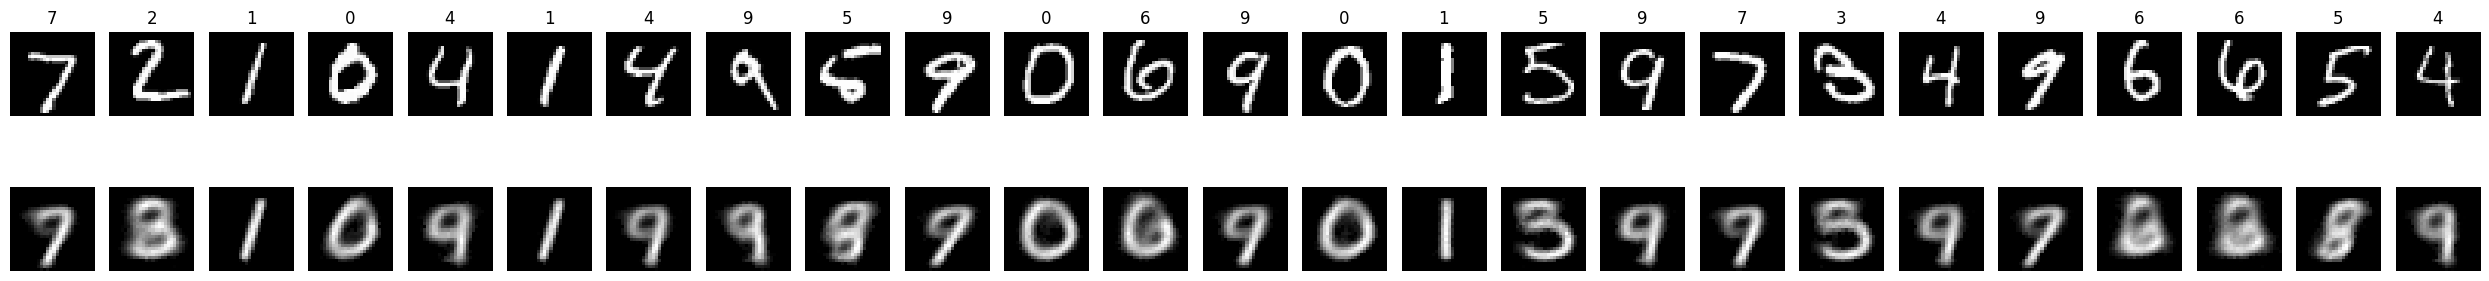

In [34]:
n_images = 25
imshape = (28, 28)

plt.figure(figsize=(25, 4))
plt.gray()

for i in range(n_images):
    orig = mnist_test[i][0]

    # ricostruzione (batch fittizio di dimensione 1 tramite unsqueeze)
    with torch.no_grad():
        recon = model(orig.unsqueeze(0).to(device)).cpu().numpy()

    # Disegna l'immagine originale (Riga 1)
    ax_orig = plt.subplot(2, n_images, i + 1)
    ax_orig.imshow(orig.numpy().reshape(imshape), cmap='gray')
    ax_orig.axis('off')
    plt.title(f"{mnist_test[i][1]}")

    # Disegna l'immagine ricostruita (Riga 2)
    ax_recon = plt.subplot(2, n_images, n_images + i + 1)
    ax_recon.imshow(recon.reshape(imshape), cmap='gray')
    ax_recon.axis('off')

plt.tight_layout()
plt.show()

### I want to see how the dataset (latente space) is plotted

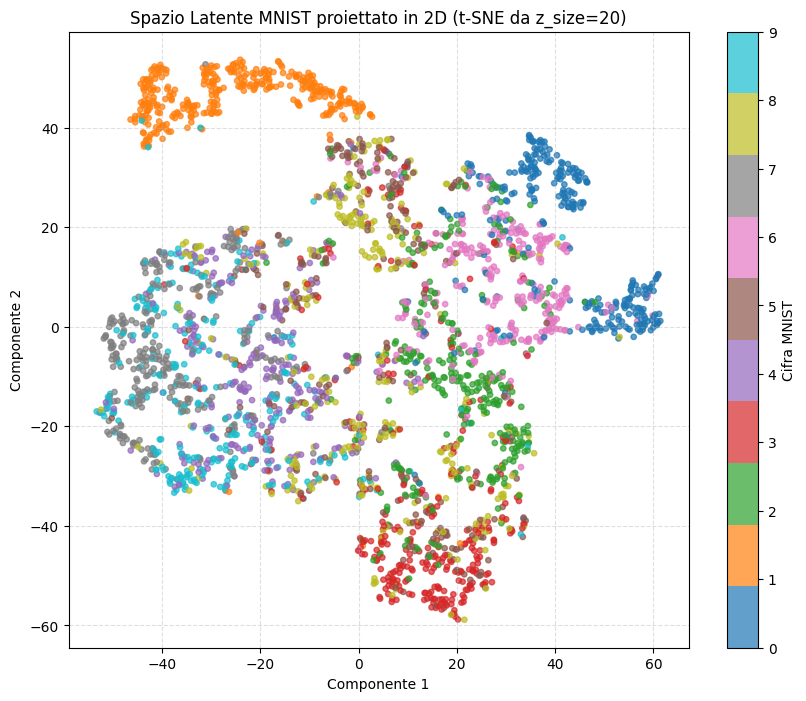

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

model.eval()

latents = []
targets = []

# 1. Estrazione delle coordinate latenti e delle etichette reali
with torch.no_grad():
    for images, labels in mnist_test_loader:
        images = images.to(device)
        z = model.encode(images)
        latents.append(z.cpu())
        targets.append(labels)

latents = torch.cat(latents, dim=0).numpy()
targets = torch.cat(targets, dim=0).numpy()

# 2. Riduzione da 20D a 2D su un campione (es. primi 3000 punti per velocità) (no PCA)
n_samples = 3000
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
z_2d = tsne.fit_transform(latents[:n_samples])
y_subset = targets[:n_samples]

# 3. Plot dello scatter plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=y_subset,
    cmap='tab10',
    alpha=0.7,
    s=15
)

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Cifra MNIST')
plt.title('Spazio Latente MNIST proiettato in 2D (t-SNE da z_size=20)')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### I want to investigate effective range of different point in latente space, because i want to generate a new data

In [45]:
# Inizializza due array NumPy di lunghezza 3 (o dinamicamente pari a model.z_size)
# model.z_size = 3

min_repr = np.full(model.z_size, 1000.0)
max_repr = np.full(model.z_size, -1000.0)

for X, y in mnist_test_loader:
    X = X.to(device)

    with torch.no_grad():
        repr = model.encode(X)

        # Aggiornamento dei 3 valori minimi e massimi
        min_repr = np.minimum(min_repr, repr.min(dim=0)[0].cpu().numpy())
        max_repr = np.maximum(max_repr, repr.max(dim=0)[0].cpu().numpy())

print('min_repr (dimensione 3):', min_repr)
print('max_repr (dimensione 3):', max_repr)

min_repr (dimensione 3): [ -6.5737319   -7.87378788 -16.67790794]
max_repr (dimensione 3): [19.31664658 17.35076904 13.83054733]


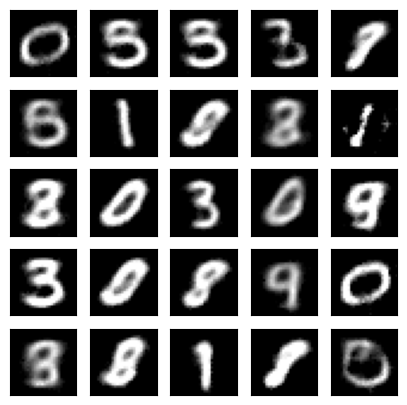

In [46]:
plt.figure(figsize=(5, 5))
plt.gray()

imshape = (28, 28)
preds = []

# Converti i 20 minimi e massimi in tensori PyTorch sul device corretto
min_t = torch.from_numpy(min_repr).float().to(device)
max_t = torch.from_numpy(max_repr).float().to(device)

for i in range(25):
    with torch.no_grad():
        # Estrae 3 numeri casuali uniformi tra 0 e 1
        rand_3d = torch.rand(1, model.z_size, device=device)

        # Mappa simultaneamente tutti i 3 valori nei rispettivi intervalli [min, max]
        z = rand_3d * (max_t - min_t) + min_t

        # Invia il vettore (1, 3) al decoder
        img_decoded = model.decode(z).clip(0, 1).cpu().float().numpy()
        preds.append(img_decoded)

# Plot della griglia 5x5
for i in range(25):
    ax = plt.subplot(5, 5, i + 1)
    ax.imshow(preds[i].reshape(imshape), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

In [43]:
min_repr = np.array([1000, 1000, 1000])
max_repr = np.array([-1000, -1000, -1000])

for X, y in mnist_test_loader:
    X = X.to(device)

    with torch.no_grad():
        repr = model.encode(X)

        min_repr = np.minimum(min_repr, repr.min(dim=0)[0].cpu().numpy())
        max_repr = np.maximum(max_repr, repr.max(dim=0)[0].cpu().numpy())


print('min_repr:', min_repr)
print('max_repr:', max_repr)

min_repr: [ -6.5737319   -7.87378788 -16.67790794]
max_repr: [19.31664658 17.35076904 13.83054733]


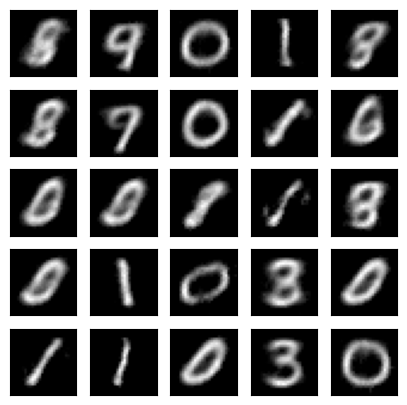

In [44]:
plt.figure(figsize=(5,5))
plt.gray()

imshape=(28,28)
preds = []

for i in range(25):
    with torch.no_grad():
        z1 = torch.rand(1, device=device) * (max_repr[0] - min_repr[0]) + min_repr[0]
        z2 = torch.rand(1, device=device) * (max_repr[1] - min_repr[1]) + min_repr[1]
        z3 = torch.rand(1, device=device) * (max_repr[2] - min_repr[2]) + min_repr[2]

        z = torch.cat([z1, z2, z3], dim=0).unsqueeze(0)
        preds.append(model.decode(z).cpu().float().numpy())


for i in range(25):
    ax = plt.subplot(5,5,i+1)
    # ax.imshow(preds[i].reshape(imshape))
    ax.imshow(preds[i].reshape(imshape), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)